# Análise Exploratória do Dataset para Treinamento de RNA

## Avaliação de Qualidade dos Dados de Simulação de Sistema Elétrico

- `PLOAD_cenario`: carga ativa do cenário (MW)
- `PGWIND_disponivel_cenario`: geração eólica disponível no cenário (MW)
- `BESS_init_cenario`: estado inicial da bateria (MW)
- `CURTAILMENT_total_result`: total de corte de geração (MW)
- `BESS_operation_result`: operação da bateria (MW)



---


## 1. Importação das bibliotecas e definição da classe `RNADataAnalyzer`

In [1]:
from StationarityAnalyzer import RNADataAnalyzer

## 2. Carregamento dos dados e visão geral

In [2]:
# Caminho para o banco de dados
db_path = r'..\DATA\output_CLAGTEE_oficial\IEEE118_RNA_DATA_ACOPF_snapshot.db'

LINHAS_14B = ["4-7","4-9","5-6"]
LINHAS_1118B = [
    "8-5",      
    "26-25",    
    "30-17",    
    "38-37",    
    "63-59",    
    "64-61",   
    "65-66",    
    "81-80",    
    "68-69"
]

# Criar instância do analisador
analyzer = RNADataAnalyzer(
    db_path=db_path,
    load_linhas=True,
    linhas_especificas=LINHAS_1118B
)
# Visão geral
analyzer.overview()

Dados principais carregados. Registros: 354000
Dados mesclados com linhas. Novo shape: (354000, 26)
Total de registros: 354000
Colunas disponíveis: ['id', 'cen_id', 'timestamp', 'data_simulacao', 'dia_semana', 'hora_simulacao', 'BAR_id', 'BAR_tipo', 'PLOAD_cenario', 'QLOAD_cenario', 'PGER_UTE_result', 'QGER_UTE_result', 'PLOSS_result', 'PDEF_result', 'PGWIND_disponivel_cenario', 'PGWIND_total_result', 'CURTAILMENT_total_result', 'BESS_init_cenario', 'BESS_operation_result', 'BESS_soc_atual_result', 'V_result', 'ANG_result', 'FLUX_result_65-66', 'FLUX_result_68-69', 'LIN_usage_result_65-66', 'LIN_usage_result_68-69']

Primeiras 5 linhas:
   id                cen_id                   timestamp data_simulacao  \
0   1  20260701203440_00000  2026-07-01T20:34:42.125944              1   
1   2  20260701203440_00000  2026-07-01T20:34:42.125944              1   
2   3  20260701203440_00000  2026-07-01T20:34:42.125944              1   
3   4  20260701203440_00000  2026-07-01T20:34:42.125944    

## 3. Estatísticas descritivas por hora



In [3]:
stats_hour = analyzer.get_hourly_stats()
display(stats_hour)

PLOAD_cenario                               \
                        mean     std  min     max   count   
hora_simulacao                                              
16                    0.3372  0.3719  0.0  2.8806  118000   
17                    0.3373  0.3723  0.0  2.8807  118000   
18                    0.3371  0.3721  0.0  2.8807  118000   

               PGWIND_disponivel_cenario                               ...  \
                                    mean     std  min     max   count  ...   
hora_simulacao                                                         ...   
16                                0.0218  0.1621  0.0  2.9745  118000  ...   
17                                0.0210  0.1582  0.0  3.0000  118000  ...   
18                                0.0211  0.1593  0.0  2.8856  118000  ...   

               PGER_UTE_result                              QGER_UTE_result  \
                          mean     std  min     max   count            mean   
hora_simulacao                                                                
16                      0.2947  1.0117  0.0  7.6597  118000          0.0331   
17                      0.2952  1.0125  0.0  7.6487  118000          0.0331   
18                      0.2950  1.0121  0.0  7.6291  118000          0.0331   

                                                
                   std     min     max   count  
hora_simulacao                                  
16              0.3518 -1.5691  2.3266  118000  
17              0.3515 -1.5813  2.3319  118000  
18              0.3508 -1.5715  2.3378  118000  

[3 rows x 30 columns]

In [4]:
stats_by_bar = analyzer.get_hourly_stats_by_bar()
print(stats_by_bar.head())

                      PLOAD_cenario                                \
                               mean     std     min     max count   
BAR_id hora_simulacao                                               
1      16                    0.4792  0.0300  0.4286  0.5303  1000   
       17                    0.4810  0.0288  0.4284  0.5303  1000   
       18                    0.4808  0.0287  0.4286  0.5304  1000   
2      16                    0.1876  0.0114  0.1680  0.2080  1000   
       17                    0.1881  0.0116  0.1681  0.2080  1000   

                      PGWIND_disponivel_cenario                       ...  \
                                           mean  std  min  max count  ...   
BAR_id hora_simulacao                                                 ...   
1      16                                   0.0  0.0  0.0  0.0  1000  ...   
       17                                   0.0  0.0  0.0  0.0  1000  ...   
       18                                   0.0  0.0  0.0  0.0

## 4. Perfil horário médio

Os gráficos abaixo mostram a média e a banda de ±1 desvio padrão para cada variável ao longo das horas do dia. A análise visual permite detectar:
- **Padrões diários**: por exemplo, a carga (`PLOAD_cenario`) geralmente apresenta picos durante o dia e vales à noite.
- **Variabilidade**: desvios grandes indicam maior dispersão dos dados naquela hora.
- **Comportamento esperado**: verificar se os perfis estão de acordo com o conhecimento do sistema (ex.: geração eólica tende a ser mais alta em certas horas).

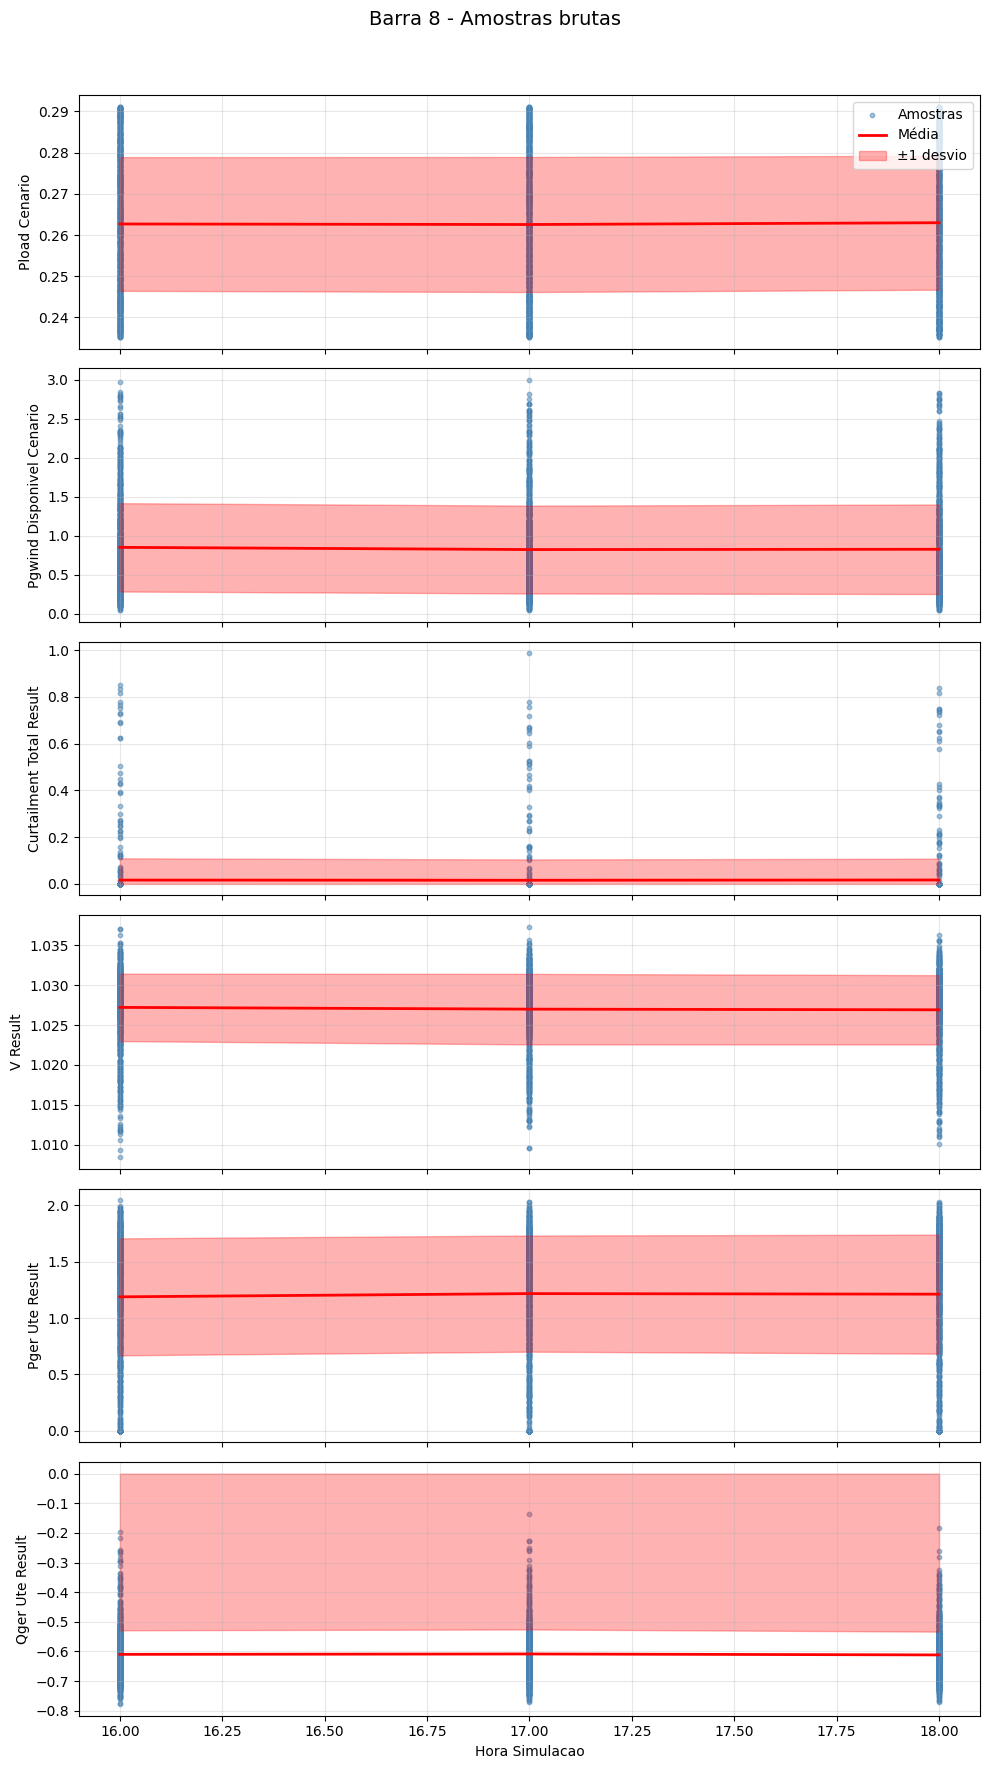

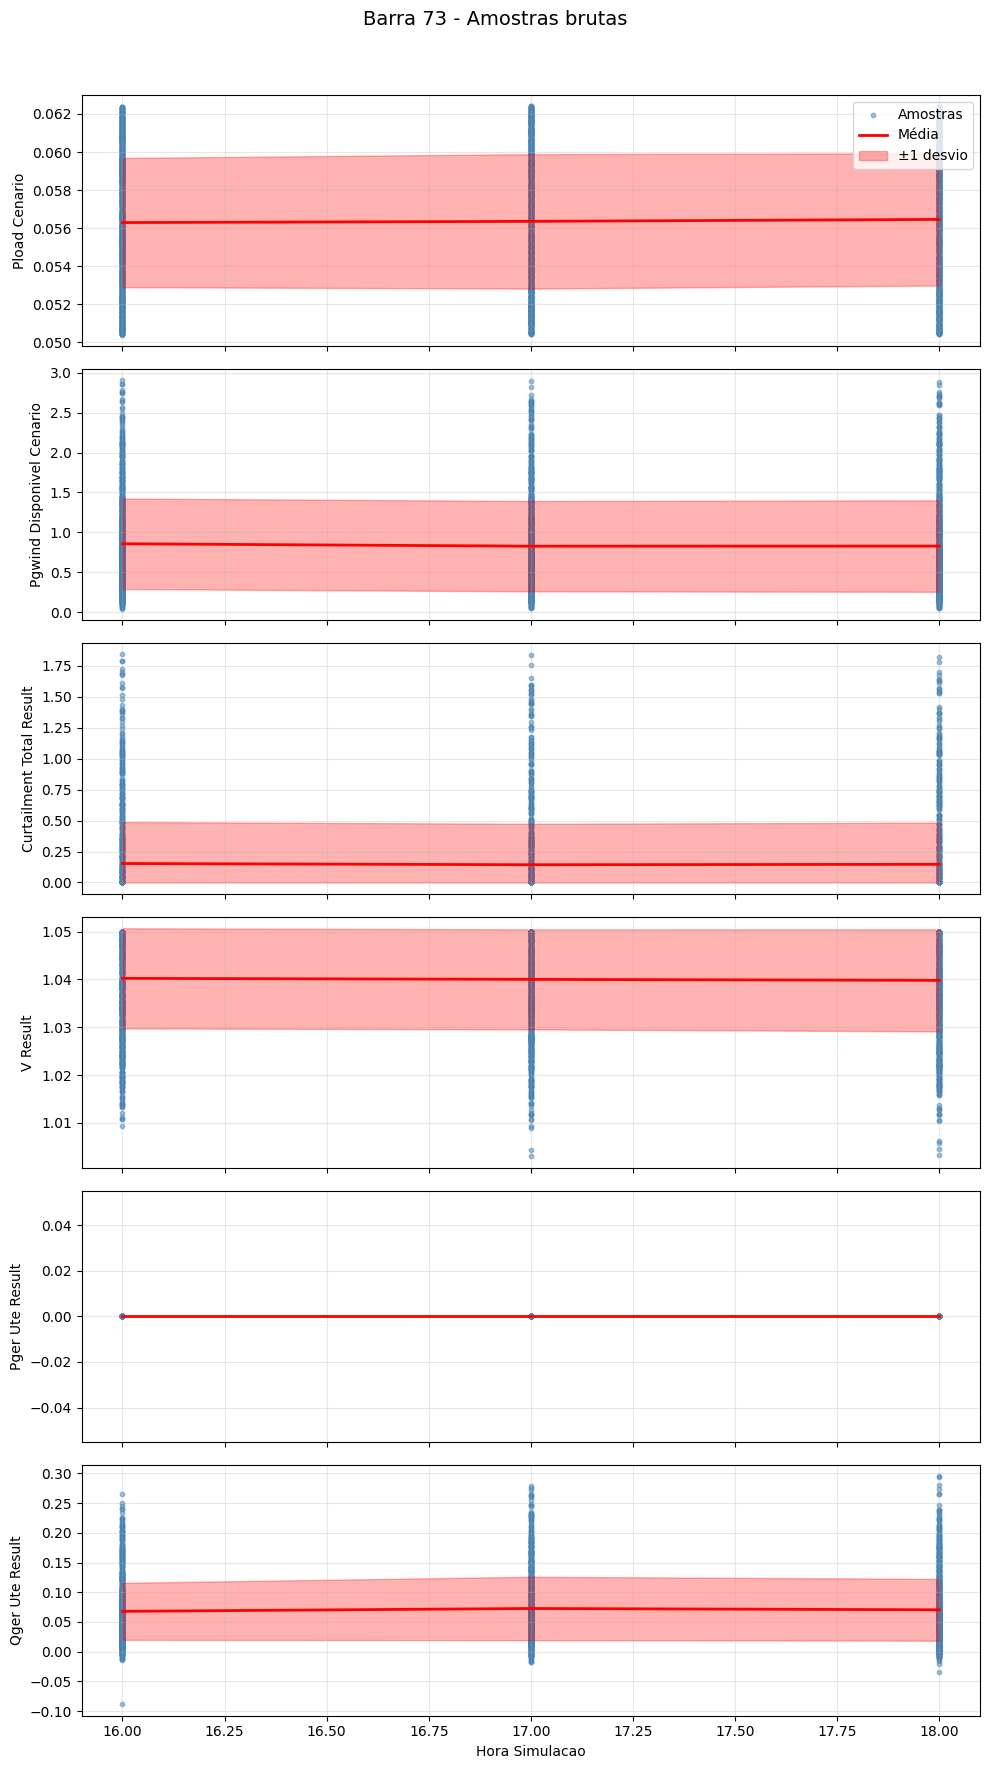

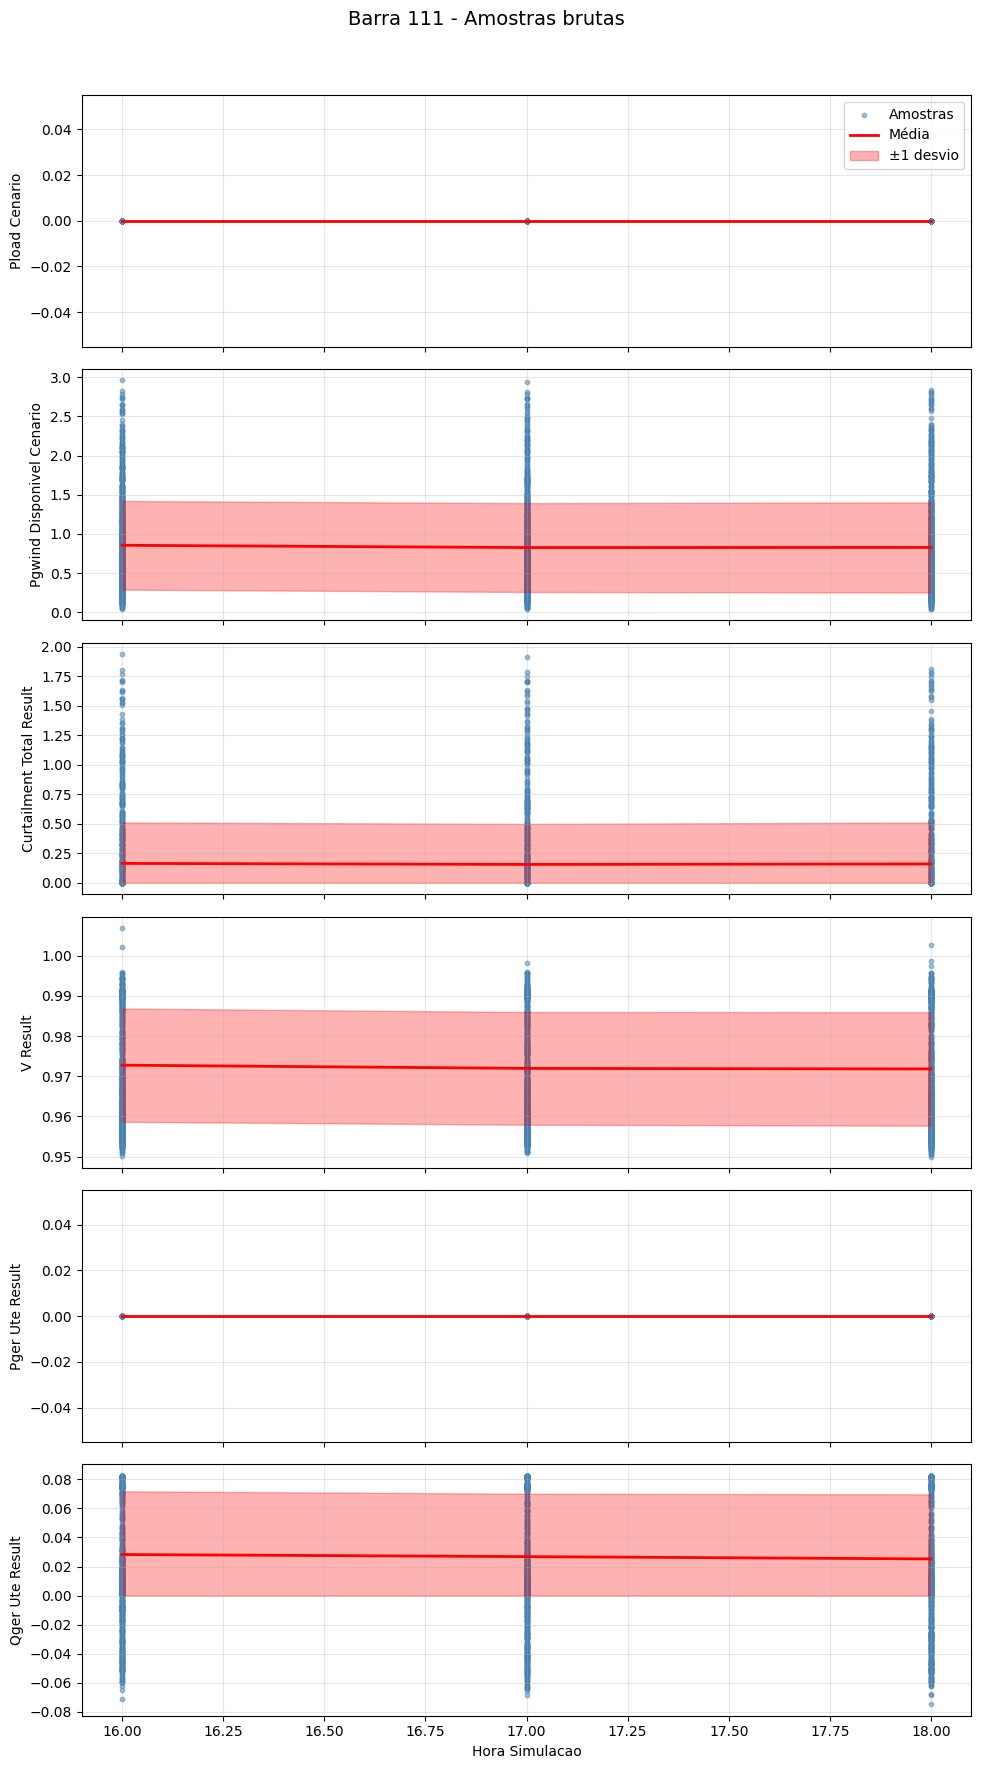

In [5]:
#analyzer.plot_raw_samples_by_bar(bar_ids=[2, 3, 4, 6, 9, 14] , show_mean_std=True)
analyzer.plot_raw_samples_by_bar(bar_ids=[8,73,111] , show_mean_std=True)

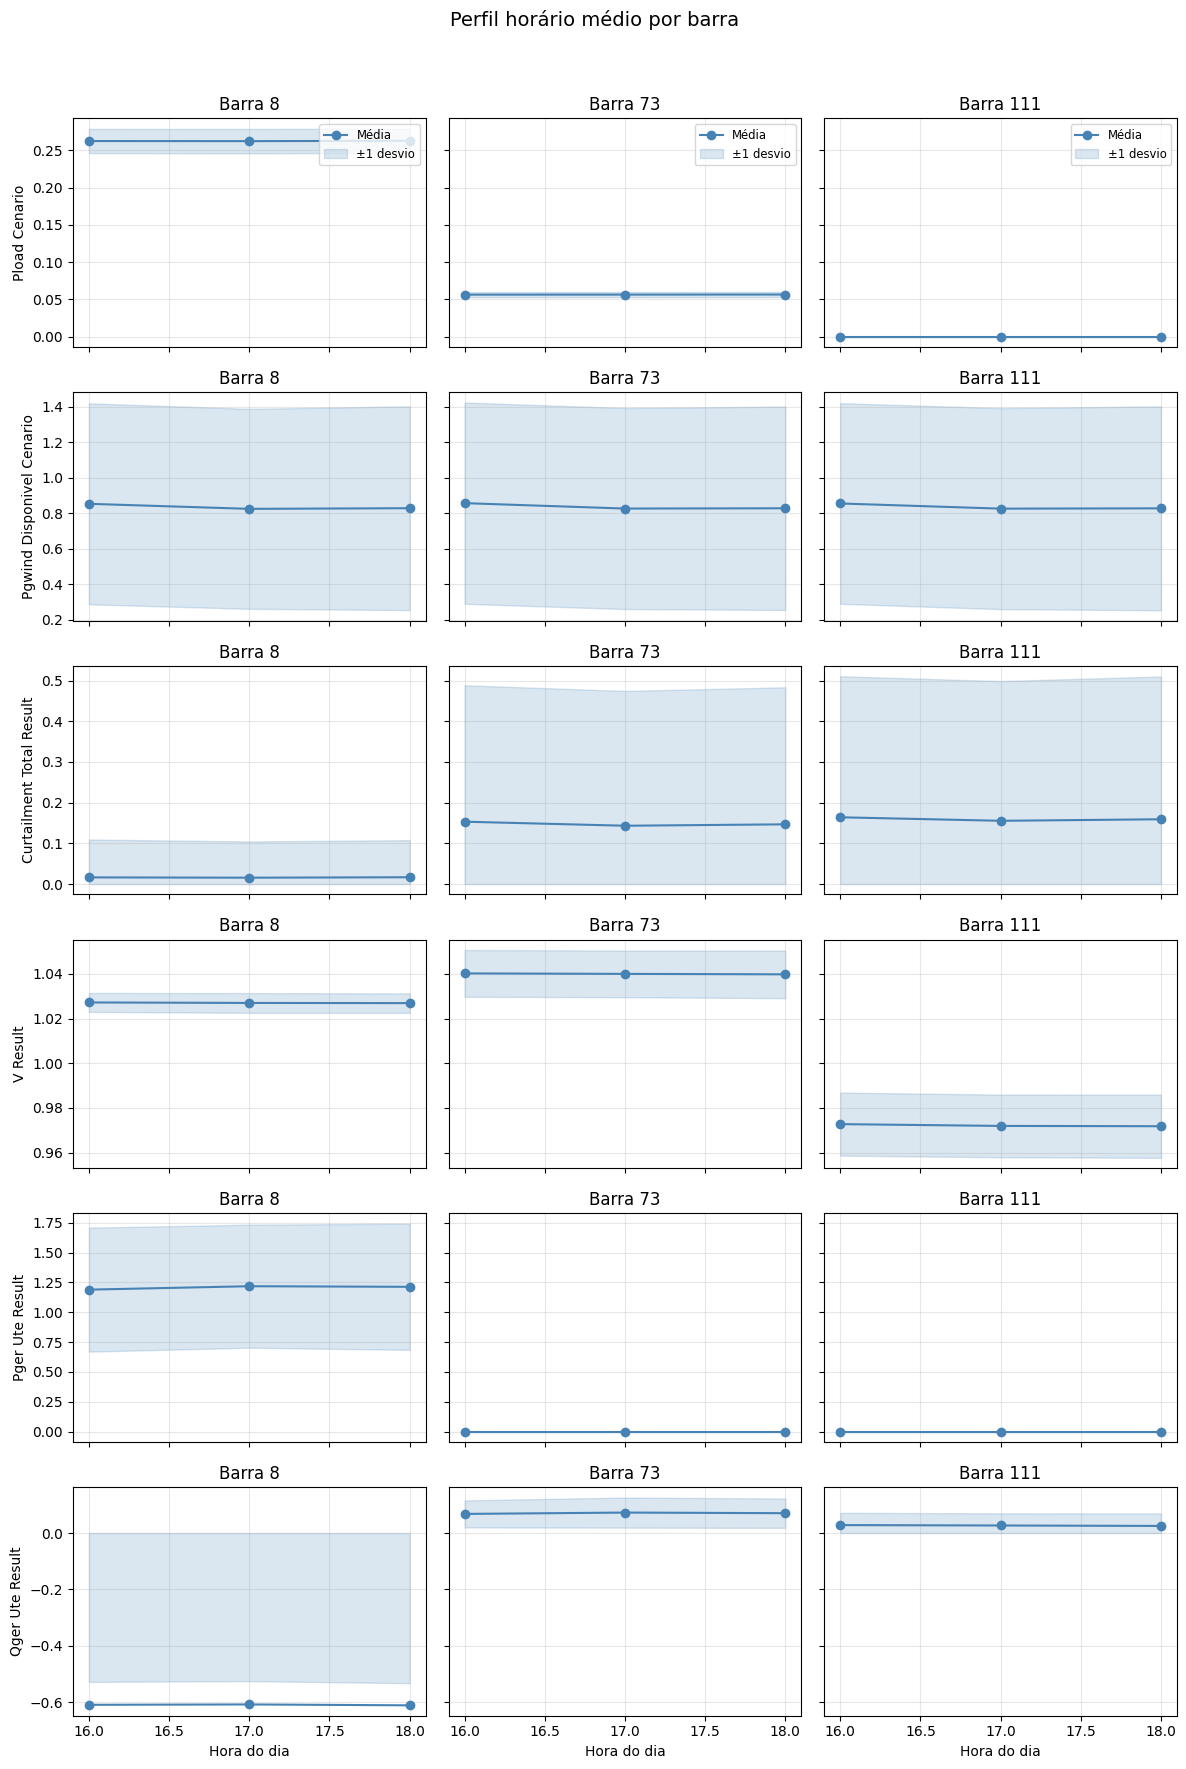

In [6]:
# Plotar perfis para todas as barras
analyzer.get_hourly_stats_by_bar(bar_ids=[8,73,111] )
analyzer.plot_hourly_profiles_by_bar(bar_ids=[8,73,111])

## 5. Matriz de correlação

A correlação entre as variáveis pode revelar relações lineares importantes. Por exemplo:
- Se `CURTAILMENT_total_result` estiver fortemente correlacionado com `PGWIND_disponivel_cenario`, faz sentido, pois o corte de geração eólica ocorre quando há excesso de vento.
- Se houver correlações inesperadas (ex.: `BESS_operation_result` fortemente correlacionado com `PLOAD_cenario`), pode indicar dependências que devem ser capturadas pelo modelo.

A matriz também ajuda a verificar multicolinearidade, que pode afetar o treinamento da rede neural.

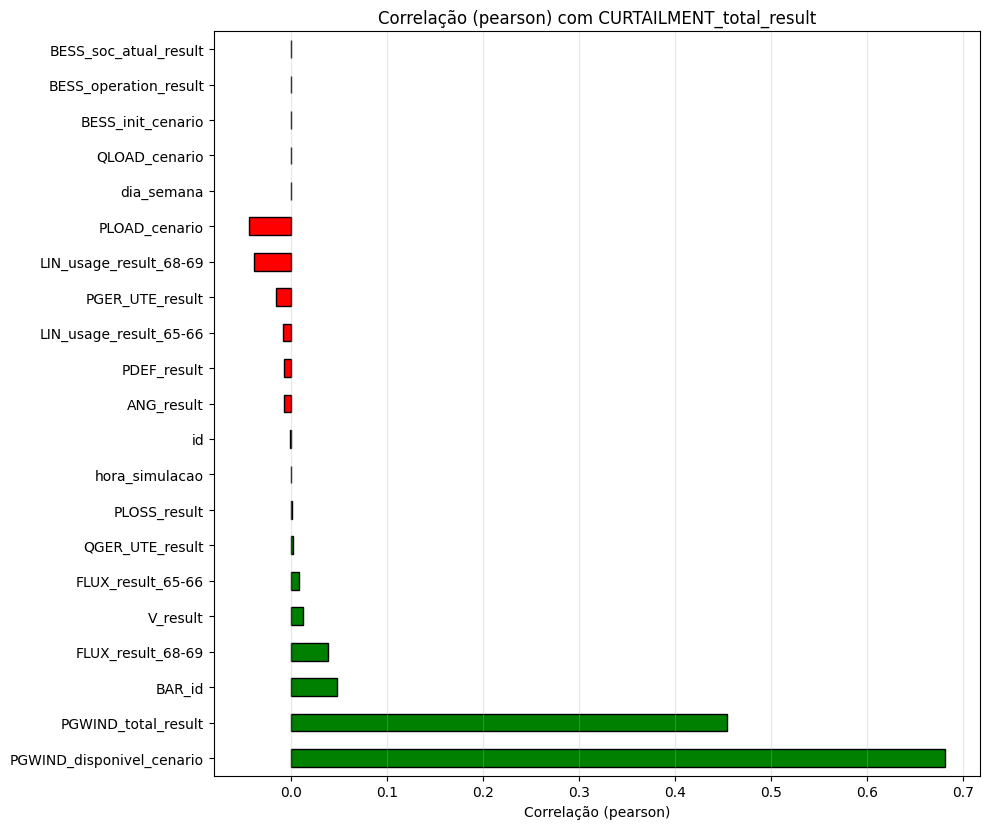

In [7]:
corr = analyzer.feature_target_correlation(target='CURTAILMENT_total_result', plot=True)

## 7. Estatísticas descritivas globais

Além da análise por hora, é útil ter uma visão geral das variáveis: média, desvio padrão, assimetria e curtose. Assimetria positiva indica cauda à direita (valores altos raros), enquanto curtose alta sugere a presença de outliers.

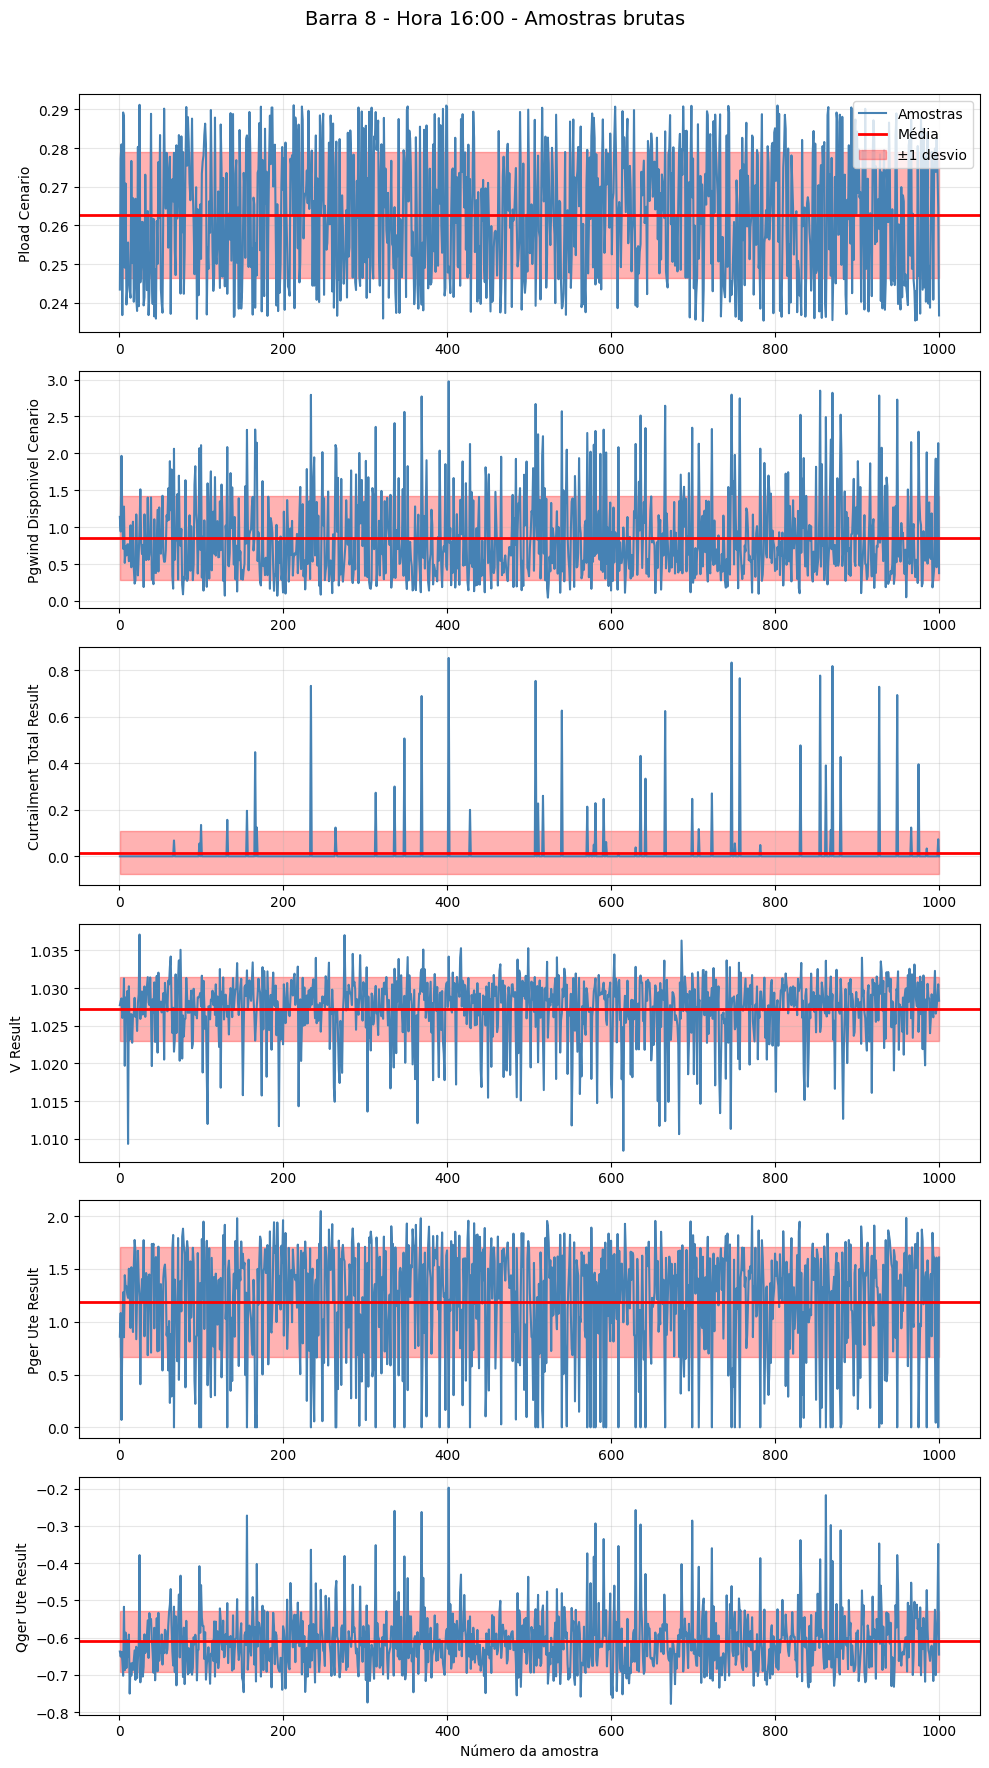

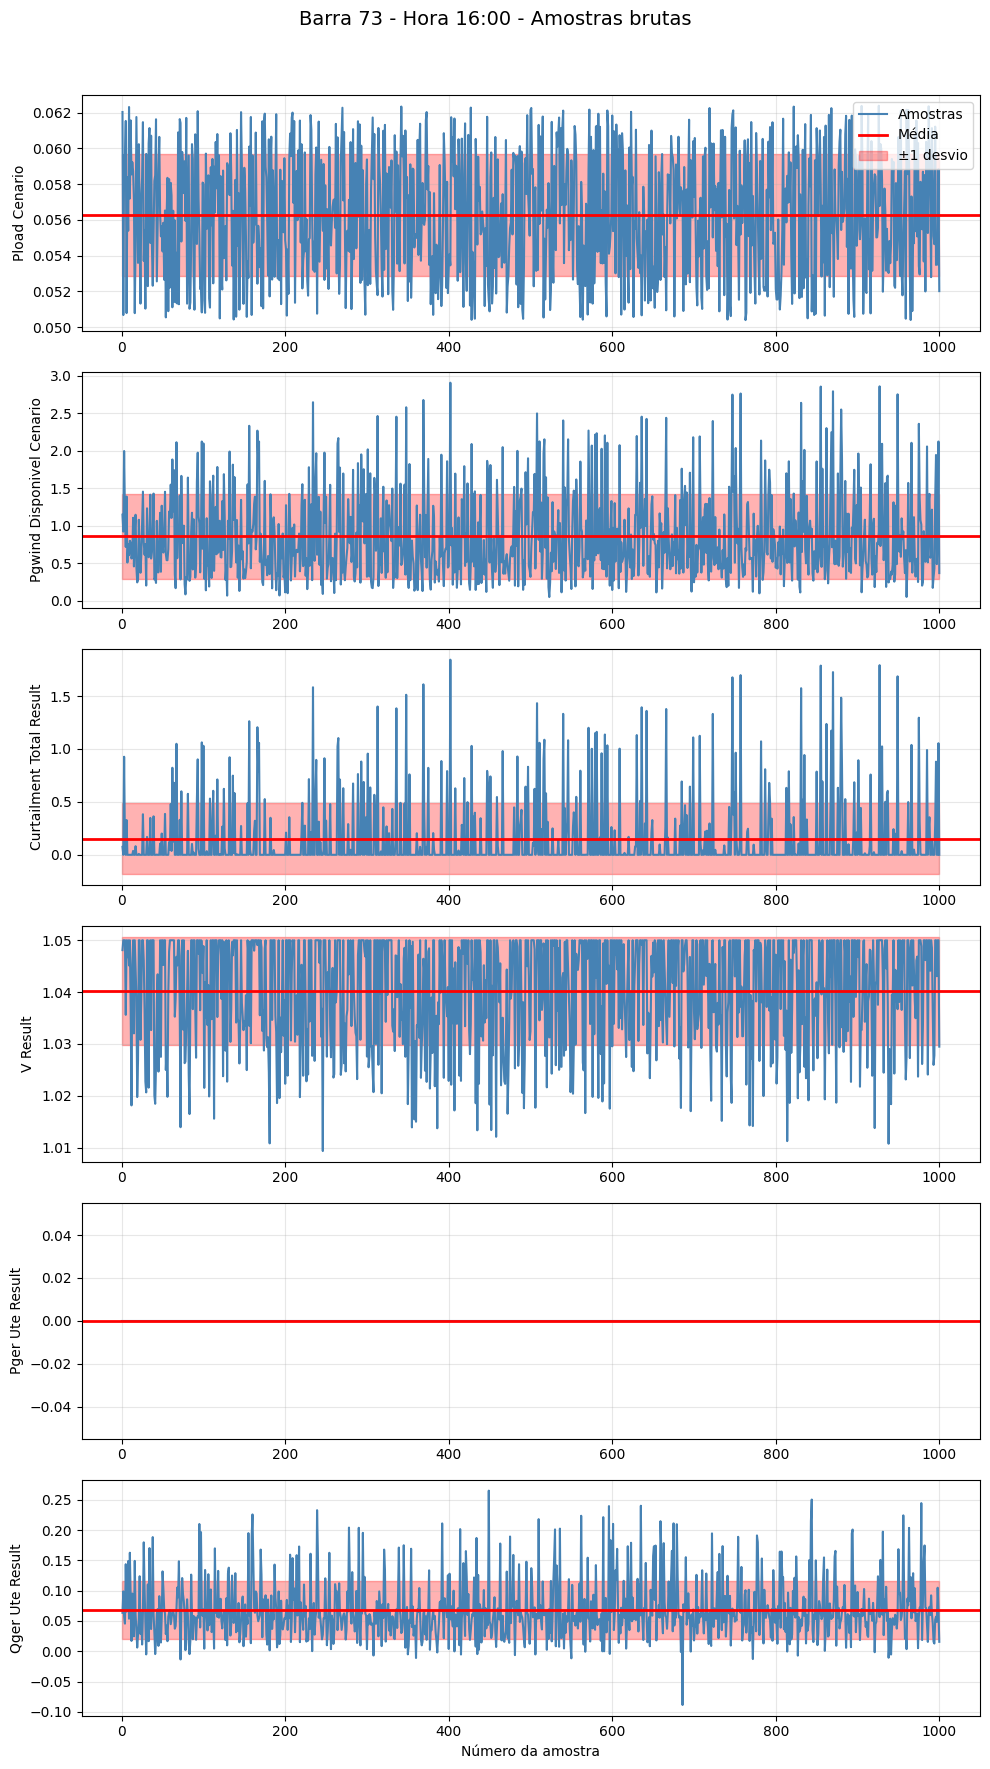

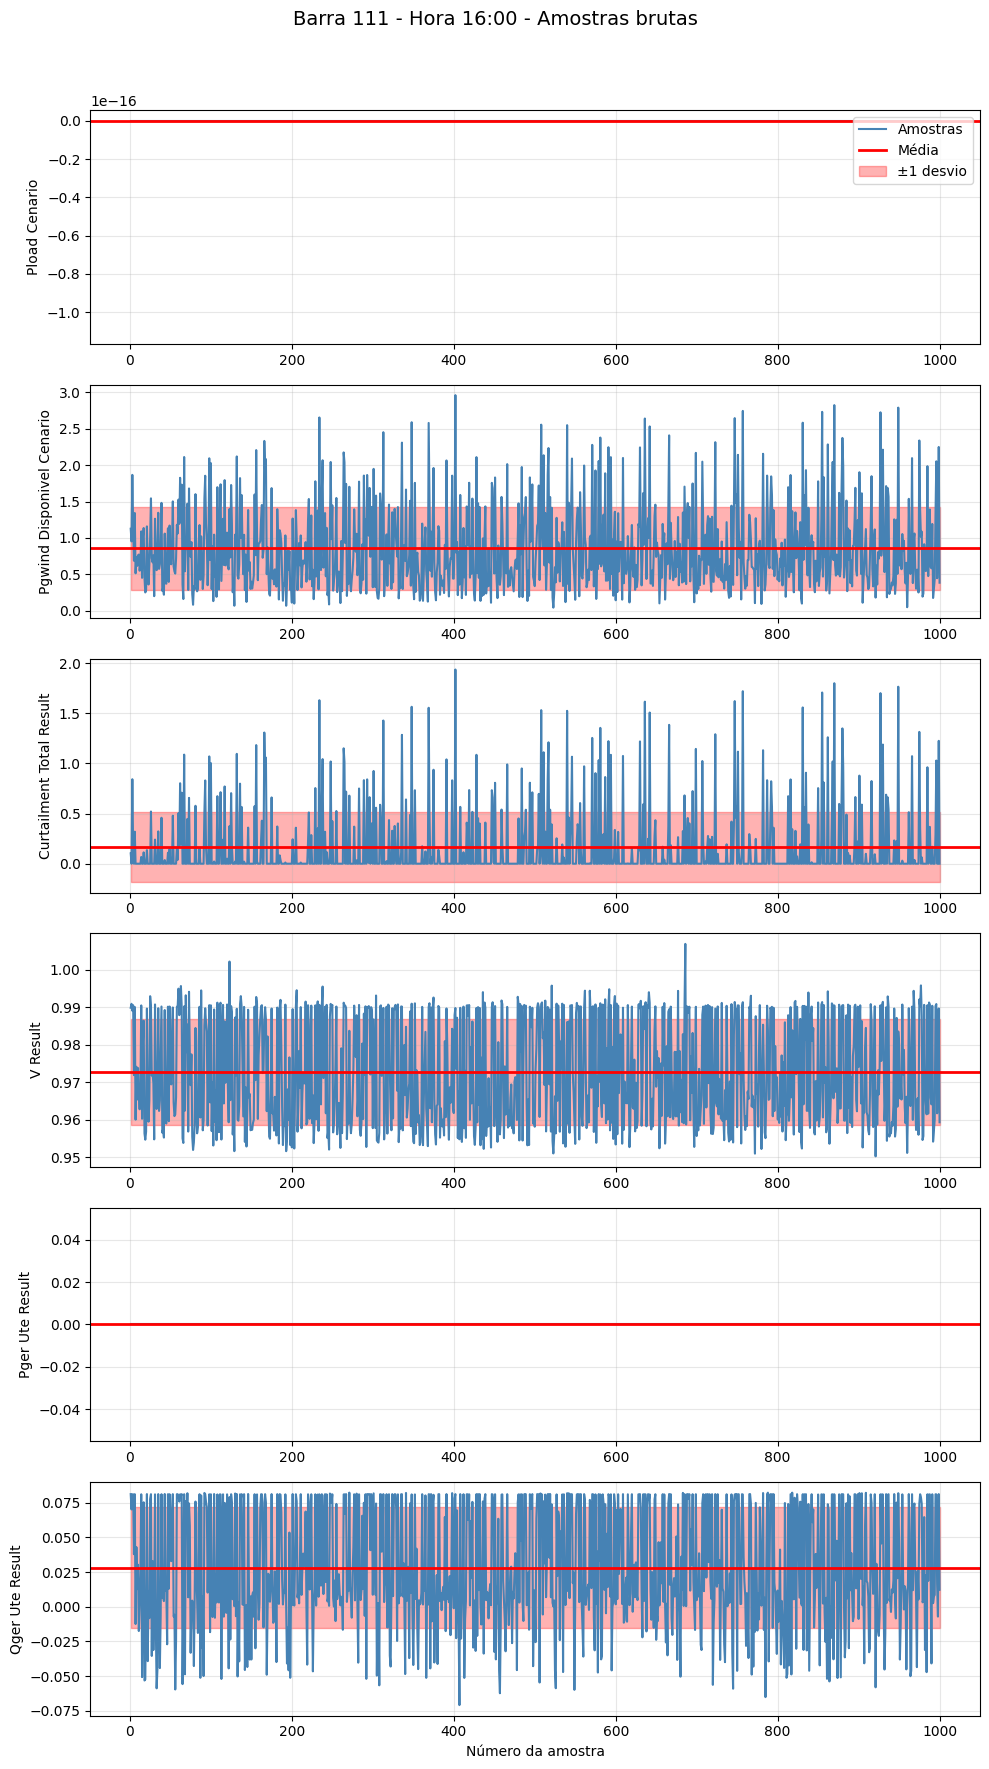

In [8]:
analyzer.plot_samples_at_hour(hour=16, bar_ids=[8,73,111]  , show_mean_std=True)

In [9]:
desc_stats = analyzer.descriptive_statistics()
display(desc_stats)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
PLOAD_cenario,354000.0,0.337237,0.372093,0.000000,0.103676,0.242342,0.465217,2.880721,2.853436,12.455974
PGWIND_disponivel_cenario,354000.0,0.021281,0.159901,0.000000,0.000000,0.000000,0.000000,3.000000,9.600350,107.230327
CURTAILMENT_total_result,354000.0,0.002742,0.049294,0.000000,0.000000,0.000000,0.000000,1.936047,22.768980,589.560261
V_result,354000.0,1.011027,0.030557,0.950000,0.988533,1.018905,1.037485,1.050000,-0.543921,-0.914258
PGER_UTE_result,354000.0,0.294958,1.012082,0.000000,0.000000,0.000000,0.000000,7.659713,4.387717,22.061487
QGER_UTE_result,354000.0,0.033076,0.351368,-1.581251,0.000000,0.000000,0.000000,2.337761,2.084726,16.557067
